In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
import joblib

In [3]:
import fastf1

In [4]:
from sklearn.metrics import ndcg_score, f1_score
from scipy.stats import spearmanr

In [38]:
import matplotlib.pyplot as plt

In [5]:
model = joblib.load('f1_xgbranker.pkl')

In [12]:
#function to collect qualifying data

def get_quali_data(track, race_completed):
    session = fastf1.get_session(2025, track, 'Qualifying')
    session.load()

    #collecting weather data
    weather_data = {
    'session_id': '2025_' + str(track),
    'season': 2025,
    'Avg_AirTemp': session.weather_data['AirTemp'].mean(),
    'Avg_Humidity': session.weather_data['Humidity'].mean(),
    'Avg_Pressure': session.weather_data['Pressure'].mean(),
    'Rainfall': session.weather_data['Rainfall'].mean(),
    'Avg_TrackTemp': session.weather_data['TrackTemp'].mean(),
    'Avg_WindSpeed': session.weather_data['WindSpeed'].mean(),
    }
    weather_data = pd.DataFrame([weather_data])   

    #collecting car data
    car_data = pd.DataFrame()
    for driver in session.drivers:
        try:
            data = session.car_data[driver].add_distance()
            driver_result = session.results[session.results['DriverNumber'] == driver]
            team = driver_result['TeamName'][0]
            position = driver_result['Position'][0]
                
            temp = {
                'Driver': driver,
                'Team': team,
                'session_id': '2025_' + str(track),
                'season': 2025,
                'Avg_Speed': data['Speed'].mean(),
                'Max_Speed': data['Speed'].max(),
                'Avg_Throttle': data['Throttle'].mean(),
                'Max_Throttle': data['Throttle'].max(),
                'Avg_RPM': data['RPM'].mean(),
                'DRS_Activations': data['DRS'].sum(),
                'GearChanges': data['nGear'].nunique(),
                'Quali_Position': position
            }
                
            car_data = pd.concat([car_data, pd.DataFrame([temp])], ignore_index=True)
        except Exception as e:
            print(f"Skipping driver {driver} in {session_id}: {e}")

    #collecting lap data
    lap_data = pd.DataFrame()
    for driver in session.drivers:
        try:
            data = session.laps.pick_driver(driver)
                
            avg_lap_time = data['LapTime'].mean()
            avg_sector_1_time = data['Sector1Time'].mean()
            avg_sector_2_time = data['Sector2Time'].mean()
            avg_sector_3_time = data['Sector3Time'].mean()
                        
            temp = {
                'Driver': driver,
                'session_id': '2025_' + str(track),
                'season': 2025,
                'Avg_Lap_Time': avg_lap_time.total_seconds()if pd.notnull(avg_sector_1_time) else None,
                'Avg_Sector_1_Time': avg_sector_1_time.total_seconds() if pd.notnull(avg_sector_1_time) else None,
                'Avg_Sector_2_Time': avg_sector_2_time.total_seconds() if pd.notnull(avg_sector_2_time) else None,
                'Avg_Sector_3_Time': avg_sector_3_time.total_seconds() if pd.notnull(avg_sector_3_time) else None
            }
                
            lap_data = pd.concat([lap_data, pd.DataFrame([temp])], ignore_index=True)
        except Exception as e:
            print(f"Skipping driver {driver} in {session_id}: {e}")

    #merging data
    driver_data = pd.merge(lap_data, car_data, on=['Driver', 'session_id', 'season'], how='inner')
    current_data = pd.merge(driver_data, weather_data, on=['session_id', 'season'], how='inner')

    #call function to clean data
    return clean_data(current_data, track, race_completed)

In [13]:
#function to clean data

def clean_data(data, track, race_completed):
    data['Driver'] = data['Driver'].astype(int)
    data['session_id'] = data['session_id'].astype(str)

    #encode Team column to match training data
    encoded_data = pd.get_dummies(data, columns=['Team'])

    #matching column order to training data
    train_columns = joblib.load('train_columns.joblib')
    X_live = encoded_data[train_columns]

    #call function to predict on X_live
    return predict(X_live, track, race_completed)

In [29]:
def predict(X_live, track, race_completed):
    predicted_scores = model.predict(X_live)
    X_live['predicted_score'] = predicted_scores
    X_live['predicted_position'] = X_live['predicted_score'].rank(ascending=True, method='first')

    results = X_live[['Driver', 'predicted_position']]

    #if race has happened, compare predictions to actual race results
    if race_completed==True:
        return race_results(results, track)
    else:
        return results.sort_values(by='predicted_position')

In [15]:
#function to create dataframe with prediction position and actual position

def race_results(results, track):
    session = fastf1.get_session(2025, track, 'Race')
    session.load()
    
    race_results = pd.DataFrame()
    for driver in session.drivers:
        try:
            driver_result = session.results[session.results['DriverNumber'] == driver]
                        
            if not driver_result.empty:
                final_position = driver_result['Position'].iloc[0] if pd.notnull(driver_result['Position'].iloc[0]) else None
            else:
                final_position = None
                            
            temp = {
                'Driver': driver,
                'Final_Race_Position': final_position
            }
            
            race_results = pd.concat([race_results, pd.DataFrame([temp])], ignore_index=True)
        except Exception as e:
            print(f"Skipping driver {driver} in {session_id}: {e}")

    race_results['Driver'] = race_results['Driver'].astype(int)
    results = pd.merge(results, race_results, on=['Driver'], how='inner')
    results = results.sort_values(by='Final_Race_Position')
    
    return metrics(results)

In [32]:
#function to evaluate model performance 

def metrics(results):
    #print predictions and actual results
    print(results)
    
    #Spearman's Rank Correlation
    true_ranks = results['Final_Race_Position']
    pred_ranks = results['predicted_position']
    corr, _ = spearmanr(true_ranks, pred_ranks)
    print("Spearman's Rank Correlation:", corr)
    
    #Normalized Discounted Cumulative Gain (NDCG)
    results2 = results.copy()
    results2['relevance'] = 1 / (results2['Final_Race_Position'] + 1)
    y_true = results2.sort_values('Final_Race_Position').head(10)['relevance'].values.reshape(1, -1)
    y_pred = results2.sort_values('predicted_position').head(10)['relevance'].values.reshape(1, -1)
    print("Normalized Discounted Cumulative Gain (NDCG):", ndcg_score(y_true, y_pred))
    
    #Reciprocal Rank
    group_sorted = results.sort_values('predicted_position').reset_index(drop=True)
    winner_index = group_sorted[group_sorted['Final_Race_Position']==1].index
    if len(winner_index) > 0:
        rr = 1.0 / (winner_index[0]+1)
    print("Reciprocal Rank:", rr)

    return corr, ndcg_score(y_true, y_pred), rr

In [ ]:
#to generate predictions for 2025 races - run this command to call previous functions
#True if race has passed and you want to calculate metrics for the model's predictions
#False if race has not passed and you want to generate predictions

SRC_Aus, NDCG_Aus, RR_Aus = get_quali_data('Australia', True)

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '81', '1', '63', '22', '23', '16', '44', '10', '55', '6', '14', '18', '7', '5', '12', '27', '30', '31', '87']
/var/folders/d9/g117yw8s09v39m9sy9t98mmc0000gn/T/ipykernel_79345/2712646214.py:26: FutureWarning: Series.__

    Driver  predicted_position  Final_Race_Position
0        4                 2.0                  1.0
2        1                 1.0                  2.0
3       63                 4.0                  3.0
15      12                11.0                  4.0
5       23                 7.0                  5.0
12      18                13.0                  6.0
16      27                18.0                  7.0
6       16                 6.0                  8.0
1       81                 3.0                  9.0
7       44                 9.0                 10.0
8       10                10.0                 11.0
4       22                 5.0                 12.0
18      31                19.0                 13.0
19      87                20.0                 14.0
17      30                 8.0                 15.0
14       5                17.0                 16.0
11      14                12.0                 17.0
9       55                15.0                 18.0
13       7  

In [34]:
SRC_China, NDCG_China, RR_China = get_quali_data('China', True)

core           INFO 	Loading data for Chinese Grand Prix - Qualifying [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

    Driver  predicted_position  Final_Race_Position
0       81                 3.0                  1.0
2        4                 4.0                  2.0
1       63                 2.0                  3.0
3        1                 1.0                  4.0
10      31                13.0                  5.0
7       12                 6.0                  6.0
9       23                14.0                  7.0
16      87                20.0                  8.0
13      18                15.0                  9.0
14      55                18.0                 10.0
6        6                 8.0                 11.0
19      30                11.0                 12.0
17       7                16.0                 13.0
18       5                19.0                 14.0
11      27                12.0                 15.0
8       22                 9.0                 16.0
12      14                10.0                 17.0
5       16                 7.0                 18.0
4       44  

In [35]:
SRC_Japan, NDCG_Japan, RR_Japan = get_quali_data('Japan', True)

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO

    Driver  predicted_position  Final_Race_Position
0        1                 1.0                  1.0
1        4                 2.0                  2.0
2       81                 4.0                  3.0
3       16                 3.0                  4.0
4       63                 6.0                  5.0
5       12                 5.0                  6.0
7       44                 9.0                  7.0
6        6                 7.0                  8.0
8       23                12.0                  9.0
9       87                13.0                 10.0
12      14                11.0                 11.0
14      22                 8.0                 12.0
10      10                10.0                 13.0
11      55                14.0                 14.0
18       7                16.0                 15.0
15      27                18.0                 16.0
13      30                15.0                 17.0
17      31                20.0                 18.0
16       5  

In [36]:
SRC_Bahrain, NDCG_Bahrain, RR_Bahrain = get_quali_data('Bahrain', True)

core           INFO 	Loading data for Bahrain Grand Prix - Qualifying [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 

    Driver  predicted_position  Final_Race_Position
0       81                 2.0                  1.0
1       63                 1.0                  2.0
5        4                 7.0                  3.0
2       16                 4.0                  4.0
8       44                 9.0                  5.0
6        1                 5.0                  6.0
4       10                 6.0                  7.0
13      31                18.0                  8.0
9       22                 8.0                  9.0
19      87                20.0                 10.0
3       12                 3.0                 11.0
14      23                19.0                 12.0
11       6                13.0                 13.0
10       7                10.0                 14.0
12      14                11.0                 15.0
16      30                16.0                 16.0
18      18                15.0                 17.0
17       5                17.0                 18.0
7       55  

In [37]:
SRC_Saudi, NDCG_Saudi, RR_Saudi = get_quali_data('Saudi Arabia', True)

core           INFO 	Loading data for Saudi Arabian Grand Prix - Qualifying [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req           

    Driver  predicted_position  Final_Race_Position
1       81                 2.0                  1.0
0        1                 1.0                  2.0
3       16                 4.0                  3.0
9        4                13.0                  4.0
2       63                 3.0                  5.0
4       12                 5.0                  6.0
6       44                 7.0                  7.0
5       55                 6.0                  8.0
10      23                11.0                  9.0
13       6                14.0                 10.0
12      14                10.0                 11.0
11      30                12.0                 12.0
14      87                15.0                 13.0
18      31                20.0                 14.0
17      27                18.0                 15.0
15      18                16.0                 16.0
16       7                17.0                 17.0
19       5                19.0                 18.0
7       22  

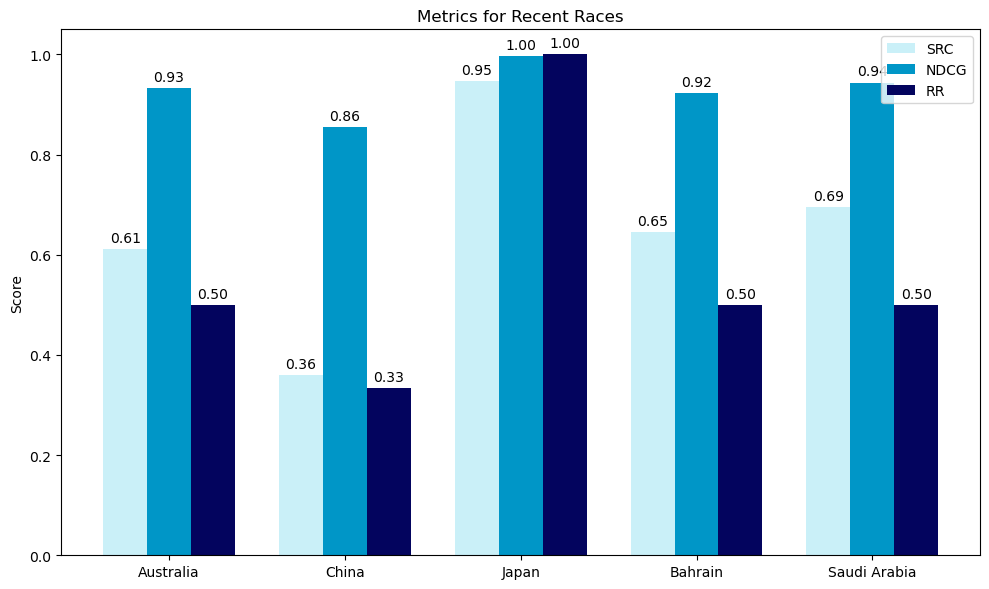

In [ ]:
#comparison of model metrics for first 5 races in 2025

races = ['Australia', 'China', 'Japan', 'Bahrain', 'Saudi Arabia']
SRC = [SRC_Aus, SRC_China, SRC_Japan, SRC_Bahrain, SRC_Saudi]
NDCG = [NDCG_Aus, NDCG_China, NDCG_Japan, NDCG_Bahrain, NDCG_Saudi]
RR = [RR_Aus, RR_China, RR_Japan, RR_Bahrain, RR_Saudi]

x = np.arange(len(races))
width = 0.25  

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, SRC, width, label='SRC', color="#CAF0F8")
rects2 = ax.bar(x, NDCG, width, label='NDCG', color="#0096C7")
rects3 = ax.bar(x + width, RR, width, label='RR', color="#03045E")

ax.set_ylabel('Score')
ax.set_title('Metrics for Recent Races')
ax.set_xticks(x)
ax.set_xticklabels(races)
ax.legend()

def annotate_bars(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

annotate_bars(rects1)
annotate_bars(rects2)
annotate_bars(rects3)

plt.tight_layout()
plt.show()

In [48]:
#average metrics across first 5 races in 2025

avg_SRC = np.mean([SRC_Aus, SRC_China, SRC_Japan, SRC_Bahrain, SRC_Saudi])
avg_NDCG = np.mean([NDCG_Aus, NDCG_China, NDCG_Japan, NDCG_Bahrain, NDCG_Saudi])
avg_RR = np.mean([RR_Aus, RR_China, RR_Japan, RR_Bahrain, RR_Saudi])

print("Average Spearman's Rank Correlation:", avg_SRC)
print("Average Normalized Discounted Cumulative Gain:", avg_NDCG)
print("Mean Reciprocal Rank:", avg_RR)

Average Spearman's Rank Correlation: 0.6514285714285715
Average Normalized Discounted Cumulative Gain: 0.9301628876197245
Mean Reciprocal Rank: 0.5666666666666667
